In [2]:
import qiskit

In [3]:
qiskit.__version__

'1.1.1'

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv('API_KEY')

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum", token=api_key)

In [6]:
QiskitRuntimeService.save_account(channel="ibm_quantum", token=api_key, set_as_default=True,overwrite=True,)

In [7]:
backend = service.backend("ibm_kyiv")

In [8]:
backend.num_qubits

127

In [9]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2 as Sampler

# create empty circuit
example_circuit = QuantumCircuit(2)
example_circuit.measure_all()

sampler = Sampler(backend)
job = sampler.run([example_circuit])
print(f"job id: {job.job_id()}")
result = job.result()
print(f"job result: {result}")

job id: cyftz959b62g0081yb6g
job result: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': {'__type__': 'ExecutionSpanCollection', '__value__': {'spans': [{'__type__': 'ExecutionSpan', '__value__': {'start': datetime.datetime(2025, 2, 2, 17, 47, 19, 701766, tzinfo=tzutc()), 'stop': datetime.datetime(2025, 2, 2, 17, 47, 29, 450004, tzinfo=tzutc()), 'data_slices': {'0': [[4096], 0, 4096]}}}]}}}, 'version': 2})


In [11]:
# Create a quantum circuit with 2 qubits and 2 classical bits
circuit = QuantumCircuit(2, 2)

# Apply gates and measure qubits into classical bits
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])

# Check classical registers
print(circuit.cregs)

[ClassicalRegister(2, 'c')]


In [13]:
# Print the results
print(result)

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': {'__type__': 'ExecutionSpanCollection', '__value__': {'spans': [{'__type__': 'ExecutionSpan', '__value__': {'start': datetime.datetime(2025, 2, 2, 17, 47, 19, 701766, tzinfo=tzutc()), 'stop': datetime.datetime(2025, 2, 2, 17, 47, 29, 450004, tzinfo=tzutc()), 'data_slices': {'0': [[4096], 0, 4096]}}}]}}}, 'version': 2})


In [14]:
raw_meas = result[0].data.meas
print(raw_meas)

BitArray(<shape=(), num_shots=4096, num_bits=2>)


In [18]:
print(dir(result))  # Inspect the attributes of result
# Or for the first subresult
print(dir(result[0]))

['__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_metadata', '_pub_results', 'metadata']
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_data', '_metadata', 'data', 'join_data', 'metadata']


In [21]:
print(dir(raw_meas))  # Show all available methods and attributes of BitArray

['__abstractmethods__', '__and__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__invert__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__non_callable_proto_members__', '__or__', '__parameters__', '__protocol_attrs__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '__xor__', '_abc_impl', '_array', '_bytes_to_bitstring', '_bytes_to_int', '_get_counts', '_is_protocol', '_is_runtime_protocol', '_num_bits', '_prepare_broadcastable', '_shape', 'array', 'bitcount', 'concatenate', 'concatenate_bits', 'concatenate_shots', 'expectation_values', 'from_bool_array', 'from_counts', 'from_samples', 'get_bitstrings', 'get_counts', 'get_int_counts', 'ndim', 'num_bits', 'num_shots', 'reshape', 'shape', 'size', '

In [22]:
# Get bitstrings from the BitArray
bitstrings = raw_meas.get_bitstrings()

# Import Counter to count the frequency of each result
from collections import Counter

counts = Counter(bitstrings)

# Display the counts
print("Counts:", counts)

Counts: Counter({'00': 4062, '01': 17, '10': 17})


In [23]:
for bitstring, count in counts.items():
    print(f"State {bitstring} occurred {count} times")

State 00 occurred 4062 times
State 01 occurred 17 times
State 10 occurred 17 times


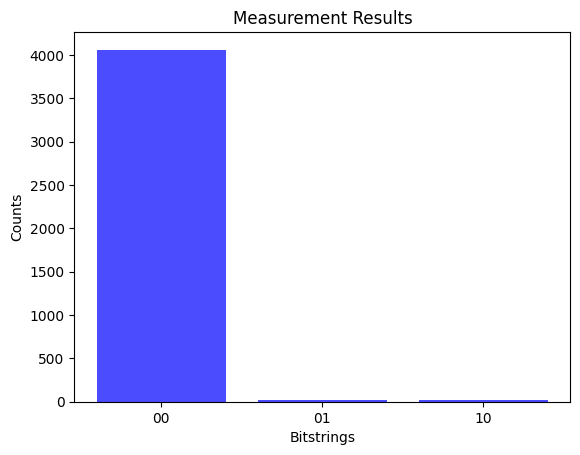

In [24]:
import matplotlib.pyplot as plt

# Convert counts to lists for plotting
labels = counts.keys()
values = counts.values()

# Create a bar plot
plt.bar(labels, values, color='blue', alpha=0.7)
plt.xlabel('Bitstrings')
plt.ylabel('Counts')
plt.title('Measurement Results')
plt.show()